<a href="https://colab.research.google.com/github/joseportocarrero-stack/DataScience-Homework/blob/main/FGD_C28R_1A_LABD13_Portocarrero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABORATORIO DIRIGIDO N.° 13

## Calidad de Datos: ponerle nota a tu base

**Curso:** Fundamentos de Gestión de Datos · TECSUP
**Docente:** Pilar Rocío Sayán Mejía
**Caso:** Farmacia MediSur — base oficial del PMD2
**Duración:** 1 hora y 40 minutos

---

### Elemento de la capacidad terminal

Mide la calidad de la base del proyecto en las cinco dimensiones (completitud, exactitud, consistencia, unicidad y oportunidad), calcula un *scorecard* con nota antes y después, aplica un pipeline de correcciones que resuelve los problemas que la migración de la Semana 10 no detectó, y deja la evidencia y la tabla limpia dentro de la base.

## Caso introductorio

La semana pasada pasó algo incómodo.

Intentaste graficar las ventas por mes y el gráfico salió roto. Descubriste que `fecha_operacion` tenía **dos formatos mezclados**: 930 fechas como `2026-01-15` y 80 como `19/01/2026`. Lo estandarizaste en memoria para poder graficar, y seguiste.

Pero quedó una pregunta en el aire, y hoy toca responderla:

> **Si tu pipeline de la Semana 10 no vio las fechas… ¿qué más se le pasó?**

Ese es el trabajo de hoy. Vas a dejar de limpiar por corazonada y vas a **medir**. Porque limpiar sin medir es adivinar: no sabes si mejoraste, ni cuánto, ni qué falta.

Y el gerente va a hacerte la pregunta más difícil de todas:

> *"¿Puedo confiar en estos datos? Dame un número."*

Un número. No "está más o menos bien". Al terminar hoy vas a poder responderle: **"la base tiene 87 sobre 100, y aquí están los tres problemas que la bajan"**.

Te adelanto lo que vas a encontrar. Además de las fechas, hay **dos problemas más que nadie ha visto**: unos documentos de identidad que no pueden existir, y casi 200 ventas que llevan meses colgadas sin cerrarse. Ninguno rompe el código. Los dos rompen el negocio.

## Actividad 1: conceptos previos

Completa con tus propias palabras.

| # | Concepto | Definición con tus propias palabras |
|---|---|---|
| 1 | Calidad de datos | Grado en el que un dato o conjunto de estos cumple con los requisitos de uso por parte de una persona u organización.|
| 2 | Perfilado de datos (*profiling*) | Es un análisis ligero, rápido y automatizado de datos, orientado a descubrir problemas de calidad. Genera un reporte como resultado.|
| 3 | Completitud | Ausencia de valores faltantes en un registro de datos.|
| 4 | Exactitud | Coincidencia entre los datos almacenados y la medida o hecho real.|
| 5 | Consistencia | Permanencia en la forma de representar un dato.|
| 6 | Unicidad | Ausencia de registros repetidos, de forma total o parcial.|
| 7 | Oportunidad | Hace referencia a que los datos deben de estar presentes en el momento necesario.|
| 8 | Regla de calidad | Conjunto de instrucciones para abordar problemas de calidad de datos o para validarla.|
| 9 | Scorecard de calidad | Graduación o calificación de la calidad en un conjunto de datos.|
| 10 | Great Expectations | Librería de Python para pruebas de calidad de datos.|

### Las cinco dimensiones de la calidad

"Datos de calidad" no significa nada hasta que lo partes en cinco preguntas concretas. Cada una se mide distinto:

| Dimensión | La pregunta que responde | Ejemplo de falla en MediSur |
|---|---|---|
| **Completitud** | ¿Está el dato? | 14 clientes sin correo |
| **Exactitud** | ¿El dato es posible? | Un DNI de 5 dígitos; una venta de −S/ 3.413 |
| **Consistencia** | ¿El mismo dato se escribe igual siempre? | `2026-01-15` y `19/01/2026` conviviendo |
| **Unicidad** | ¿Está una sola vez? | El mismo DNI en dos filas |
| **Oportunidad** | ¿Sigue vigente y a tiempo? | Una venta "Pendiente" desde hace 5 meses |

Fíjate en la diferencia entre **exactitud** y **completitud**, que es la que más se confunde:

- Un correo **vacío** es un problema de **completitud**: falta.
- Un correo que dice `juanperezcorreo.com` (sin arroba) es un problema de **exactitud**: está, pero es imposible.

El segundo es más peligroso. Un dato vacío se nota. Un dato **falso pero con formato de verdadero** se cuela hasta que alguien intenta usarlo.

### Por qué medir antes de limpiar

Tu pipeline de la Semana 10 limpió duplicados, correos y montos. Estuvo bien. Pero no puedes responder: **¿cuánto mejoró?** No lo mediste antes.

Hoy el orden es: **medir → corregir → volver a medir**. La diferencia entre los dos números es tu evidencia. Sin ella, "limpiamos la base" es una afirmación sin respaldo.

## Actividad 2: desarrollo práctico en Colab

---

### Paso 1: recuperar el proyecto

Como siempre, recuperamos lo construido: la base migrada (S10), su catálogo (S11) y las funciones del sistema. Si te falta algo, se reconstruye solo.

**Ojo a algo importante:** hoy vamos a medir **dos** bases. La original sucia (`farmacia_legacy.db`) y la migrada (`farmacia_migrada.db`). Comparar las dos es lo que te da el "antes y después" real.

In [ ]:
# ============================================================
# Paso 1: recuperar el proyecto (semanas 10, 11 y 12)
# ============================================================
import sqlite3, os, re
import pandas as pd
import numpy as np

caso = "03_farmacia_medisur"          # <-- cambia por la carpeta de TU caso asignado
DB_ORIGEN  = "farmacia_legacy.db"     # la base sucia: el "antes"
DB_DESTINO = "farmacia_migrada.db"    # la base del proyecto: el "despues"

REPO = "Rociosayan/-PMD2_FGD_Bases_Oficiales_FDG"
url  = f"https://raw.githubusercontent.com/{REPO}/main/casos/{caso}/{caso}.db"

TABLAS_DEL_SISTEMA = {"catalogo_metadatos", "ficha_dublin_core", "resumen_etl"}
HOY = pd.Timestamp("2026-07-15")      # fecha de la sesion: sirve para medir OPORTUNIDAD


def descargar():
    if os.path.exists(DB_ORIGEN):
        return
    import requests
    r = requests.get(url)
    if r.status_code == 200 and r.content[:16] == b"SQLite format 3\x00":
        open(DB_ORIGEN, "wb").write(r.content); print("Base oficial descargada.")
    else:
        from google.colab import files
        print("Sube manualmente el .db de tu caso:")
        s = files.upload(); open(DB_ORIGEN, "wb").write(list(s.values())[0])


def migracion_semana10():
    o = sqlite3.connect(DB_ORIGEN); d = sqlite3.connect(DB_DESTINO)
    cli = pd.read_sql_query("SELECT * FROM clientes", o).drop_duplicates(
        subset=["num_documento"], keep="first")
    for col in ["nombres", "apellidos", "distrito", "segmento", "tipo_documento"]:
        cli[col] = cli[col].astype("string").str.strip().str.title()
    ok = cli["correo"].str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", na=False)
    cli["correo_fue_corregido"] = cli["correo"].notna() & ~ok
    cli.loc[~ok, "correo"] = pd.NA
    cli["correo"]   = cli["correo"].fillna("SIN CORREO REGISTRADO")
    cli["telefono"] = cli["telefono"].fillna("000000000")
    cli.to_sql("clientes_limpio", d, if_exists="replace", index=False)

    op = pd.read_sql_query("SELECT * FROM operaciones", o)
    ids_c = set(pd.read_sql_query("SELECT id_cliente FROM clientes", o)["id_cliente"])
    ids_e = set(pd.read_sql_query("SELECT id_empleado FROM empleados", o)["id_empleado"])
    op["monto_original"]     = op["monto_total"]
    op["monto_ajustado"]     = np.where(op["monto_total"] < 0, 0, op["monto_total"])
    op["monto_fue_ajustado"] = op["monto_total"] < 0
    op["cliente_valido"]     = op["id_cliente"].isin(ids_c)
    op["empleado_valido"]    = op["id_empleado"].isin(ids_e)
    op.to_sql("ventas_limpia", d, if_exists="replace", index=False)

    ya = set(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", d)["name"])
    for t in ["sedes", "empleados", "productos_servicios", "detalle_operacion",
              "pagos", "incidencias"]:
        if t not in ya:
            pd.read_sql_query(f"SELECT * FROM {t}", o).to_sql(t, d, if_exists="replace", index=False)
    d.commit(); o.close(); d.close()


def catalogo_semana11():
    c = sqlite3.connect(DB_DESTINO)
    tablas = [t for t in pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", c)["name"]
        if t not in TABLAS_DEL_SISTEMA]
    filas = []
    for tabla in tablas:
        info = pd.read_sql_query(f"PRAGMA table_info({tabla})", c)
        n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {tabla}", c)["n"][0]
        for _, col in info.iterrows():
            filas.append({"tabla": tabla, "columna": col["name"],
                          "tipo_dato": col["type"] or "SIN TIPO", "registros_tabla": n})
    cat = pd.DataFrame(filas)
    DELICADO = {"01_clinica_vitalsalud":("diagnostico","Sensible"),
        "02_banco_crediandes":("saldo_cuenta","Sensible"),
        "03_farmacia_medisur":("condicion_cronica","Sensible"),
        "04_vet_cuidapatas":("motivo_atencion_mascota","Interno"),
        "05_hotel_andes_stay":("nacionalidad","Confidencial"),
        "06_logiexpress_urbano":("direccion_entrega","Confidencial"),
        "07_universidad_aula360":("promedio_notas","Confidencial"),
        "08_muni_data":("tipo_tramite","Interno"),
        "09_retail_online_market":("tarjeta_terminacion","Confidencial"),
        "10_agroexport_sol":("pais_destino","Interno"),
        "11_energyhome_servicios":("consumo_kwh","Confidencial"),
        "12_seguros_protege":("monto_asegurado","Sensible"),
        "13_fastfood_norte":("direccion_delivery","Confidencial"),
        "14_manufactura_metaltec":("linea_credito","Sensible"),
        "15_telconorte_movil":("numero_linea","Confidencial")}
    SENS = {"num_documento":"Confidencial","correo":"Confidencial","telefono":"Confidencial",
            "nombres":"Interno","apellidos":"Interno","nombre_producto":"Publico",
            "categoria":"Publico","precio_base":"Publico","activo":"Publico"}
    col_caso, niv = DELICADO[caso]; SENS[col_caso] = niv
    cat["sensibilidad"] = cat["columna"].map(lambda x: SENS.get(x, "Interno"))
    cat["descripcion_negocio"] = "Ver catalogo de la Semana 11"
    cat.to_sql("catalogo_metadatos", c, if_exists="replace", index=False)
    c.commit(); c.close()


descargar()
if not os.path.exists(DB_DESTINO):
    migracion_semana10(); print("Semana 10 reconstruida.")
conn = sqlite3.connect(DB_DESTINO)
hay_cat = len(pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' AND name='catalogo_metadatos'", conn))
conn.close()
if not hay_cat:
    catalogo_semana11(); print("Semana 11 reconstruida.")

conn = sqlite3.connect(DB_DESTINO)

# --- funciones del sistema (semanas 11 y 12)
NIVEL_ACCESO = {"Vendedor":{"Publico","Interno"}, "Cajero":{"Publico","Interno"},
                "Supervisor":{"Publico","Interno","Confidencial"},
                "Auditor":{"Publico","Interno","Confidencial","Sensible"},
                "DataOwner":{"Publico","Interno","Confidencial","Sensible"}}

def columnas_visibles(tabla, rol):
    permitidos = NIVEL_ACCESO.get(rol, set())
    if not permitidos: return []
    cat = pd.read_sql_query(
        "SELECT columna, sensibilidad FROM catalogo_metadatos WHERE tabla = ?",
        conn, params=(tabla,))
    return [c for c, s in zip(cat["columna"], cat["sensibilidad"]) if s in permitidos]

def ver_clientes(rol, limite=8):
    cols = columnas_visibles("clientes_limpio", rol)
    if not cols: return f"ACCESO DENEGADO: el rol {rol} no puede consultar."
    return pd.read_sql_query(f"SELECT {', '.join(cols)} FROM clientes_limpio LIMIT {limite}", conn)

print("Proyecto recuperado.")
print("  Base ORIGEN (sucia)  :", DB_ORIGEN, f"({os.path.getsize(DB_ORIGEN)/1024:.0f} KB)")
print("  Base DESTINO (migrada):", DB_DESTINO, f"({os.path.getsize(DB_DESTINO)/1024:.0f} KB)")
print("  Fecha de hoy (para medir Oportunidad):", HOY.date())

Proyecto recuperado.
  Base ORIGEN (sucia)  : farmacia_legacy.db (336 KB)
  Base DESTINO (migrada): farmacia_migrada.db (468 KB)
  Fecha de hoy (para medir Oportunidad): 2026-07-15


### Paso 2: las cinco reglas de calidad

Aquí está la idea central de la semana: **una dimensión no es un adjetivo, es una regla que se puede ejecutar**.

"Los datos deben estar completos" no sirve. Lo que sirve es: *"la columna `correo` no debe tener nulos"*, y eso es una línea de código que devuelve un número.

Cada función de abajo mide **una** dimensión y devuelve cuántos registros la incumplen. Fíjate en que ninguna corrige nada todavía: **primero medir, después tocar**.

In [ ]:
# ============================================================
# Paso 2: las 5 dimensiones, convertidas en reglas ejecutables
# ============================================================
def medir_completitud(cli):
    """Cuenta nulos y marcas de ausencia sin duplicarlos. Regla Nueva: El distrito del cliente no puede ser nulo o vacío(Actividad3B)."""

    fallas = {}

    marcas_ausencia = [
        "SIN CORREO REGISTRADO",
        "000000000"
    ]

    for col in ["correo", "telefono", "distrito", "segmento"]:

        if col not in cli.columns:
            continue

        es_nulo = cli[col].isna() #(Actividad3B)

        es_marca = (
            cli[col]
            .astype("string")
            .str.strip()
            .str.upper()
            .isin(marcas_ausencia)
        )

        es_nulo = cli[col].isna()
        fallas[col] = int((es_nulo | es_marca).sum())

    return fallas

def medir_exactitud(cli, op):
    """EXACTITUD: el dato esta, pero, es posible? Un DNI de 5 digitos no existe."""
    fallas = {}
    correos = cli["correo"].astype(str)
    reales  = correos != "SIN CORREO REGISTRADO"
    fallas["correo_sin_formato_valido"] = int(
        (reales & ~correos.str.match(r"^[^@\s]+@[^@\s]+\.[^@\s]+$", na=False)).sum())

    # Un DNI peruano tiene EXACTAMENTE 8 digitos. Ni 7 ni 9.
    dni = cli[cli["tipo_documento"].astype(str).str.upper() == "DNI"]["num_documento"].astype(str)
    fallas["dni_no_tiene_8_digitos"] = int((~dni.str.match(r"^[0-9]{8}$")).sum())

    tel = cli["telefono"].astype(str)
    tel_real = tel != "000000000"
    fallas["telefono_no_tiene_9_digitos"] = int((tel_real & ~tel.str.match(r"^[0-9]{9}$")).sum())

    col_monto = "monto_original" if "monto_original" in op.columns else "monto_total"
    fallas["venta_con_monto_negativo"] = int((op[col_monto] < 0).sum())
    return fallas


def medir_consistencia(cli, op):
    """CONSISTENCIA: el mismo dato, escrito siempre igual."""
    fallas = {}
    # Lo que descubriste la semana pasada: dos formatos de fecha conviviendo.
    iso = op["fecha_operacion"].astype(str).str.match(r"^\d{4}-\d{2}-\d{2}$")
    fallas["fecha_fuera_del_formato_ISO"] = int((~iso).sum())
    return fallas


def medir_unicidad(cli, op):
    """UNICIDAD: cada cosa, una sola vez."""
    return {
        "documento_duplicado":  int(cli["num_documento"].duplicated().sum()),
        "codigo_cliente_duplicado": int(cli["codigo_cliente"].duplicated().sum()),
        "codigo_venta_duplicado":   int(op["codigo_operacion"].duplicated().sum()),
    }


def _fechas(serie):
    f = pd.to_datetime(serie, format="%Y-%m-%d", errors="coerce")
    faltan = f.isna()
    f[faltan] = pd.to_datetime(serie[faltan], format="%d/%m/%Y", errors="coerce")
    return f


def medir_oportunidad(cli, op):
    """OPORTUNIDAD: el dato sigue vigente? llego a tiempo?"""
    fallas = {}
    f = _fechas(op["fecha_operacion"].astype(str))
    fallas["venta_con_fecha_futura"] = int((f > HOY).sum())
    # Una venta "Pendiente" de hace meses no es una venta: es un dato podrido.
    fallas["venta_pendiente_hace_mas_de_30_dias"] = int(
        ((op["estado"] == "Pendiente") & (f < HOY - pd.Timedelta(days=30))).sum())
    fr = pd.to_datetime(cli["fecha_registro"], errors="coerce")
    fallas["cliente_con_registro_futuro"] = int((fr > HOY).sum())
    return fallas


DIMENSIONES = {
    "Completitud":  lambda cli, op: medir_completitud(cli),
    "Exactitud":    medir_exactitud,
    "Consistencia": medir_consistencia,
    "Unicidad":     medir_unicidad,
    "Oportunidad":  medir_oportunidad,
}
print("5 dimensiones convertidas en reglas ejecutables:", list(DIMENSIONES))

5 dimensiones convertidas en reglas ejecutables: ['Completitud', 'Exactitud', 'Consistencia', 'Unicidad', 'Oportunidad']


### Paso 3: el scorecard — ponerle nota a la base

Ahora convertimos las fallas en **una nota sobre 100**.

La fórmula es honesta y simple: por cada dimensión, `100 − (registros que fallan ÷ registros totales × 100)`. Si ninguna fila falla, es 100. Si fallan todas, es 0.

Vamos a medir **las dos bases**: la sucia original y la migrada por tu pipeline. Ahí verás cuánto sirvió realmente la Semana 10.

In [ ]:
# ============================================================
# Paso 3: el scorecard de calidad
# ============================================================
def cargar(db, tabla_cli, tabla_op):
    c = sqlite3.connect(db)
    cli = pd.read_sql_query(f"SELECT * FROM {tabla_cli}", c)
    op  = pd.read_sql_query(f"SELECT * FROM {tabla_op}", c)
    c.close()
    return cli, op


def scorecard(cli, op, etiqueta):
    """Nota de 0 a 100 por dimension. 100 = ninguna fila falla."""
    filas = []
    for dim, medir in DIMENSIONES.items():
        fallas = medir(cli, op)
        total_fallas = sum(fallas.values())
        universo = len(cli) * len([k for k in fallas]) or 1
        nota = max(0, 100 - (total_fallas / universo * 100))
        filas.append({"dimension": dim, "registros_con_falla": total_fallas,
                      "nota": round(nota, 1), "detalle": fallas})
    d = pd.DataFrame(filas)
    d["base"] = etiqueta
    return d


cli_antes, op_antes = cargar(DB_ORIGEN, "clientes", "operaciones")
cli_dsp,   op_dsp   = cargar(DB_DESTINO, "clientes_limpio", "ventas_limpia")

sc_antes = scorecard(cli_antes, op_antes, "ANTES (base sucia)")
sc_dsp   = scorecard(cli_dsp,   op_dsp,   "DESPUES (migrada S10)")

print("SCORECARD DE CALIDAD")
print("=" * 60)
comparacion = pd.DataFrame({
    "dimension":   sc_antes["dimension"],
    "fallas_antes": sc_antes["registros_con_falla"],
    "nota_antes":   sc_antes["nota"],
    "fallas_despues": sc_dsp["registros_con_falla"],
    "nota_despues":   sc_dsp["nota"],
})
comparacion["mejora"] = (comparacion["nota_despues"] - comparacion["nota_antes"]).round(1)
display(comparacion)

print(f"NOTA GLOBAL ANTES  : {sc_antes['nota'].mean():.1f} / 100")
print(f"NOTA GLOBAL DESPUES: {sc_dsp['nota'].mean():.1f} / 100")
print()
print("Detalle de lo que SIGUE fallando en la base migrada:")
for _, f in sc_dsp.iterrows():
    pendientes = {k: v for k, v in f["detalle"].items() if v > 0}
    if pendientes:
        print(f"   {f['dimension']:14s} -> {pendientes}")

SCORECARD DE CALIDAD


,dimension,fallas_antes,nota_antes,fallas_despues,nota_despues,mejora
0,Completitud,42,95.0,50,93.8,-1.2
1,Exactitud,56,93.3,13,98.4,5.1
2,Consistencia,80,61.5,80,60.4,-1.1
3,Unicidad,6,99.0,0,100.0,1.0
4,Oportunidad,196,68.6,196,67.7,-0.9


NOTA GLOBAL ANTES  : 83.5 / 100
NOTA GLOBAL DESPUES: 84.1 / 100

Detalle de lo que SIGUE fallando en la base migrada:
   Completitud    -> {'correo': 25, 'telefono': 16, 'distrito': 9}
   Exactitud      -> {'dni_no_tiene_8_digitos': 5, 'venta_con_monto_negativo': 8}
   Consistencia   -> {'fecha_fuera_del_formato_ISO': 80}
   Oportunidad    -> {'venta_pendiente_hace_mas_de_30_dias': 196}


**Pregunta 1:** ¿Cuál fue la nota global antes y después de la migración de la Semana 10? Ahora mira la columna `mejora`: **¿en qué dimensiones tu pipeline mejoró la base y en cuáles la dejó igual?** ¿Por qué crees que pasó eso?

Respuesta: La nota global antes de la migración fue de 83.5 sobre cien, y la nota global después de la migración es 84.1 sobre cien. Las dimensiones Exactitud y Unicidad fue mejoradas en 5.1 y 1.0 puntos porcentuales, respectivamente, en tanto que las dimensiones Completitud, Consistencia y Oportunidad quedaron peor que antes, con bajas de 1.2, 1.1 y 0.9 puntos porcentuales, respectivamente. Esto es porque el pipeline implementado se enfocó en eliminar duplicados y limpiar errores como los montos negativos, pero no puede hacer transformaciones en completitud, consistencia y oportunidad, lo que se nota en las fechas con diferente formato y las ventas pendientes de más de 30 días.

### Paso 4: los tres problemas que nadie había visto

Mira el detalle de lo que sigue fallando. Hay tres cosas que tu pipeline de la Semana 10 **nunca tocó**, porque nunca las buscó:

| Problema | Dimensión | Por qué se coló |
|---|---|---|
| Fechas en dos formatos | **Consistencia** | El ETL no miró las fechas. Lo descubriste en la S12 |
| DNI que no tienen 8 dígitos | **Exactitud** | El ETL revisó si el DNI se **repetía**, no si era **posible** |
| Ventas "Pendiente" hace meses | **Oportunidad** | Nadie mira el calendario. El dato no está mal escrito: está **podrido** |

El tercero es el más interesante y el que más cuesta ver. Una venta pendiente de hace cinco meses **no está mal escrita**: tiene su fecha válida, su monto correcto, su cliente real. Pasa todas las validaciones de formato. Pero **como dato de negocio, es mentira**: esa venta ni se cobró ni se canceló. Está en el limbo, inflando tus reportes.

Vamos a verlos de cerca.

In [ ]:
# ============================================================
# Paso 4: los tres problemas invisibles, de cerca
# ============================================================
print("=" * 66)
print("1. EXACTITUD: documentos de identidad imposibles")
print("=" * 66)
dni_malos = cli_dsp[
    (cli_dsp["tipo_documento"].astype(str).str.upper() == "DNI") &
    (~cli_dsp["num_documento"].astype(str).str.match(r"^[0-9]{8}$"))
][["id_cliente", "nombres", "apellidos", "tipo_documento", "num_documento"]]
print(f"Clientes con DNI que NO tiene 8 digitos: {len(dni_malos)}")
display(dni_malos)
print("Un DNI peruano tiene exactamente 8 digitos. Estos no pueden existir.")
print("La S10 elimino los DNI REPETIDOS, pero nunca pregunto si eran POSIBLES.")

print()
print("=" * 66)
print("2. CONSISTENCIA: dos formatos de fecha conviviendo")
print("=" * 66)
f_iso = op_dsp["fecha_operacion"].astype(str).str.match(r"^\d{4}-\d{2}-\d{2}$")
print(f"Fechas en formato ISO (2026-01-15) : {int(f_iso.sum())}")
print(f"Fechas en otro formato (19/01/2026): {int((~f_iso).sum())}")
display(op_dsp[~f_iso][["codigo_operacion", "fecha_operacion", "estado"]].head(5))

print()
print("=" * 66)
print("3. OPORTUNIDAD: ventas podridas en el limbo")
print("=" * 66)
fechas = _fechas(op_dsp["fecha_operacion"].astype(str))
colgadas = op_dsp[(op_dsp["estado"] == "Pendiente") & (fechas < HOY - pd.Timedelta(days=30))].copy()
colgadas["dias_colgada"] = (HOY - fechas[colgadas.index]).dt.days
print(f"Ventas 'Pendiente' con mas de 30 dias: {len(colgadas)} de {len(op_dsp)}")
print(f"La mas antigua lleva {int(colgadas['dias_colgada'].max())} dias sin cerrarse.")
print(f"Dinero atrapado en el limbo: S/. {colgadas['monto_ajustado'].sum():,.2f}")
display(colgadas[["codigo_operacion", "fecha_operacion", "estado",
                  "monto_ajustado", "dias_colgada"]].sort_values(
                  "dias_colgada", ascending=False).head(5))
print()
print("Ninguna de estas filas esta mal escrita. Todas pasan las validaciones de formato.")
print("Pero como dato de NEGOCIO son mentira: ni se cobraron ni se cancelaron.")

1. EXACTITUD: documentos de identidad imposibles
Clientes con DNI que NO tiene 8 digitos: 5


,id_cliente,nombres,apellidos,tipo_documento,num_documento
1,2,Melissa,Torres Lévano,Dni,377593
52,53,Ana,Zevallos Quispe,Dni,659460
101,102,Paola,Mendoza Sánchez,Dni,377392
140,141,Ricardo,Salazar Rojas,Dni,730851
144,145,Miguel,Aguirre Quispe,Dni,390569


Un DNI peruano tiene exactamente 8 digitos. Estos no pueden existir.
La S10 elimino los DNI REPETIDOS, pero nunca pregunto si eran POSIBLES.

2. CONSISTENCIA: dos formatos de fecha conviviendo
Fechas en formato ISO (2026-01-15) : 930
Fechas en otro formato (19/01/2026): 80


,codigo_operacion,fecha_operacion,estado
5,O00006,19/01/2026,Completado
14,O00015,24/01/2026,Completado
40,O00041,27/06/2026,Completado
44,O00045,09/06/2026,Observado
56,O00057,11/02/2026,Observado



3. OPORTUNIDAD: ventas podridas en el limbo
Ventas 'Pendiente' con mas de 30 dias: 196 de 1010
La mas antigua lleva 195 dias sin cerrarse.
Dinero atrapado en el limbo: S/. 105,547.78


,codigo_operacion,fecha_operacion,estado,monto_ajustado,dias_colgada
422,O00423,2026-01-01,Pendiente,513.28,195
981,O00982,2026-01-03,Pendiente,612.09,193
98,O00099,2026-01-05,Pendiente,361.85,191
707,O00708,2026-01-05,Pendiente,648.06,191
334,O00335,2026-01-05,Pendiente,264.00,191



Ninguna de estas filas esta mal escrita. Todas pasan las validaciones de formato.
Pero como dato de NEGOCIO son mentira: ni se cobraron ni se cancelaron.


**Pregunta 2:** De los tres problemas, el de las **ventas colgadas** no rompe ninguna regla de formato: la fecha es válida, el monto es correcto, el cliente existe. Explica con tus palabras **por qué es un problema de calidad igual**, y qué decisión de negocio se tomaría mal si nadie lo detecta.

Respuesta: Porque representan transacciones estancadas, que no reflejan la realidad financiera actual de la empresa. Si nadie detecta este problema, la gerencia podría contar con ingresos que en realidad están perdidos o incobrables, lo que puede llevar a realizar inversiones o gastos basados en un capital inexistente. Se pueden estar ocultando problemas en la gestión de cobranzas. Podrían diseñarse campañas de publicidad con datos distorsionados de ventas.

### Paso 5: el pipeline de correcciones

Ahora sí, corregimos. Pero con dos reglas de oro que casi nadie sigue:

1. **Nunca borrar el dato original.** Se corrige en una columna nueva y se marca qué se tocó. Si mañana el auditor pregunta, tienes la evidencia.
2. **No todo se corrige igual.** Hay tres tipos de arreglo, y confundirlos es lo que arruina una base:

| Tipo | Qué se hace | Ejemplo |
|---|---|---|
| **Estandarizar** | El dato es correcto, solo está mal escrito | `19/01/2026` → `2026-01-19` |
| **Marcar** | El dato es imposible, pero no sabemos el verdadero | DNI de 5 dígitos → se marca como inválido |
| **Escalar** | No es un problema de datos, es del negocio | Ventas colgadas → van a una lista para el supervisor |

Fíjate en lo que **no** hacemos: **inventar**. No le ponemos un DNI cualquiera al cliente para que "pase la validación". Un dato inventado es peor que un dato faltante, porque el faltante se nota y el inventado no.

In [ ]:
# ============================================================
# Paso 5: pipeline de correcciones (sin destruir el original)
# ============================================================
def corregir_clientes(cli):
    """Corrige clientes. Nunca borra el original: marca y agrega columnas."""
    d = cli.copy()

    # --- EXACTITUD: DNI imposible. No lo inventamos: lo MARCAMOS.
    es_dni = d["tipo_documento"].astype(str).str.upper() == "DNI"
    valido = d["num_documento"].astype(str).str.match(r"^[0-9]{8}$")
    d["documento_es_valido"] = ~es_dni | valido
    d["documento_observado"] = es_dni & ~valido

    return d


def corregir_ventas(op):
    """Corrige ventas. Estandariza fechas y escala lo que es del negocio."""
    d = op.copy()

    # --- CONSISTENCIA: estandarizar el formato de fecha (el dato es correcto)
    d["fecha_original"] = d["fecha_operacion"]
    fechas = _fechas(d["fecha_operacion"].astype(str))
    d["fecha_operacion"] = fechas.dt.strftime("%Y-%m-%d")
    d["fecha_fue_estandarizada"] = d["fecha_original"] != d["fecha_operacion"]

    # --- OPORTUNIDAD: no corregimos, ESCALAMOS. Es decision del negocio.
    d["dias_desde_operacion"] = (HOY - fechas).dt.days
    d["venta_colgada"] = (d["estado"] == "Pendiente") & (d["dias_desde_operacion"] > 30)

    return d


cli_corregido = corregir_clientes(cli_dsp)
op_corregido  = corregir_ventas(op_dsp)

print("PIPELINE DE CORRECCIONES APLICADO")
print("=" * 52)
print(f"Documentos marcados como observados : {int(cli_corregido['documento_observado'].sum())}")
print(f"Fechas estandarizadas               : {int(op_corregido['fecha_fue_estandarizada'].sum())}")
print(f"Ventas escaladas al supervisor      : {int(op_corregido['venta_colgada'].sum())}")
print()
print("Ninguna fila fue borrada. Ningun dato fue inventado.")
print(f"Clientes: {len(cli_dsp)} -> {len(cli_corregido)}")
print(f"Ventas  : {len(op_dsp)} -> {len(op_corregido)}")
print()
print("Ejemplo: fechas que se estandarizaron (el original queda guardado)")
display(op_corregido[op_corregido["fecha_fue_estandarizada"]][
    ["codigo_operacion", "fecha_original", "fecha_operacion"]].head(5))

PIPELINE DE CORRECCIONES APLICADO
Documentos marcados como observados : 5
Fechas estandarizadas               : 80
Ventas escaladas al supervisor      : 196

Ninguna fila fue borrada. Ningun dato fue inventado.
Clientes: 202 -> 202
Ventas  : 1010 -> 1010

Ejemplo: fechas que se estandarizaron (el original queda guardado)


,codigo_operacion,fecha_original,fecha_operacion
5,O00006,19/01/2026,2026-01-19
14,O00015,24/01/2026,2026-01-24
40,O00041,27/06/2026,2026-06-27
44,O00045,09/06/2026,2026-06-09
56,O00057,11/02/2026,2026-02-11


**Pregunta 3:** El pipeline **marca** los DNI inválidos en vez de corregirlos, y **escala** las ventas colgadas en vez de cerrarlas. Explica por qué en esos dos casos **no** corresponde que el equipo de datos arregle el dato por su cuenta. ¿Quién debería decidir?

Respuesta: Porque el equipo de datos no conoce los números correctos de los DNI inválidos, y porque las ventas colgadas no son un problema técnico, sino de negocio. Quien debería decidir es aquel que conoce el dato y su utilidad en el negocio (Data Owner), aunque no necesariamente debe ser la misma persona para cada situación. Puede ser Atención al Cliente o Registro para los DNI, y Créditos y Cobranzas o la Gerencia de Ventas (Supervisores) para ventas colgadas.

### Paso 6: volver a medir — el antes y el después de verdad

Este es el paso que separa a un profesional de alguien que "limpia datos": **medir otra vez** y demostrar la mejora con un número.

EVOLUCION DE LA CALIDAD


,dimension,sucia,migrada_S10,corregida_S13,ganancia_S13
0,Completitud,95.0,93.8,93.8,0.0
1,Exactitud,93.3,98.4,98.4,0.0
2,Consistencia,61.5,60.4,100.0,39.6
3,Unicidad,99.0,100.0,100.0,0.0
4,Oportunidad,68.6,67.7,67.7,0.0


Base sucia         : 83.5 / 100
Despues de la S10  : 84.1 / 100   (+0.6)
Despues de hoy     : 92.0 / 100   (+7.9)

LA RESPUESTA AL GERENTE: la base tiene 92 sobre 100.


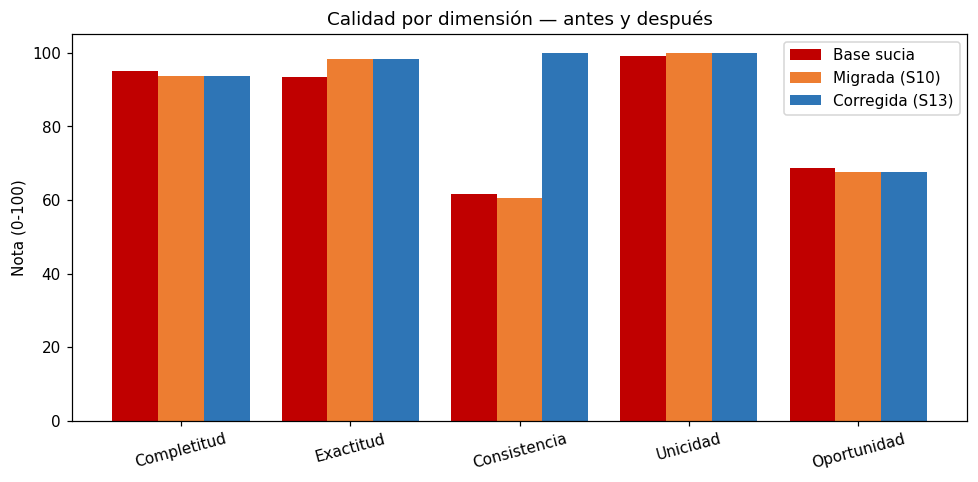

In [ ]:
# ============================================================
# Paso 6: scorecard final y grafico antes/despues
# ============================================================
sc_final = scorecard(cli_corregido, op_corregido, "FINAL (S13)")

resumen = pd.DataFrame({
    "dimension":     sc_antes["dimension"],
    "sucia":         sc_antes["nota"],
    "migrada_S10":   sc_dsp["nota"],
    "corregida_S13": sc_final["nota"],
})
resumen["ganancia_S13"] = (resumen["corregida_S13"] - resumen["migrada_S10"]).round(1)

print("EVOLUCION DE LA CALIDAD")
print("=" * 60)
display(resumen)

n_sucia = sc_antes["nota"].mean(); n_s10 = sc_dsp["nota"].mean(); n_s13 = sc_final["nota"].mean()
print(f"Base sucia         : {n_sucia:.1f} / 100")
print(f"Despues de la S10  : {n_s10:.1f} / 100   (+{n_s10-n_sucia:.1f})")
print(f"Despues de hoy     : {n_s13:.1f} / 100   (+{n_s13-n_s10:.1f})")
print()
print(f"LA RESPUESTA AL GERENTE: la base tiene {n_s13:.0f} sobre 100.")


def grafico_calidad():
    from matplotlib.figure import Figure
    fig = Figure(figsize=(9, 4.5)); ax = fig.subplots()
    x = np.arange(len(resumen)); w = 0.27
    ax.bar(x - w, resumen["sucia"],         w, label="Base sucia",       color="#C00000")
    ax.bar(x,     resumen["migrada_S10"],   w, label="Migrada (S10)",    color="#ED7D31")
    ax.bar(x + w, resumen["corregida_S13"], w, label="Corregida (S13)",  color="#2E75B6")
    ax.set_xticks(x); ax.set_xticklabels(resumen["dimension"], rotation=15)
    ax.set_ylabel("Nota (0-100)"); ax.set_ylim(0, 105)
    ax.set_title("Calidad por dimensión — antes y después")
    ax.legend(); fig.tight_layout()
    return fig


fig = grafico_calidad()
fig.savefig("calidad_antes_despues.png", bbox_inches="tight", dpi=110)
from IPython.display import Image
Image("calidad_antes_despues.png")

**Pregunta 4:** ¿Cuánto subió la nota global con tu trabajo de hoy? Mira la columna `ganancia_S13`: **¿qué dimensión ganó más y cuál no ganó nada?** Explica por qué la dimensión que no ganó **seguirá igual** aunque limpies mil veces.

Respuesta: La nota global subió en unos 7.9 puntos porcentuales. La dimensión que ganó más fue Consistencia, con una subida de 39.6 puntos porcentuales. Las que no ganaron nada fueron Completitud, Exactitud y Oportunidad. Hasta el momento se han terminado de corregir los problemas técnicos de la base. Los problemas de Exactitud (DNI inválidos) y Oportunidad (ventas colgadas) no se van a arreglar con más líneas de código, sino con decisiones de los jefes de área respectivas.

### Paso 7: guardar la tabla limpia y las reglas

Guardamos tres cosas en la base:

- `clientes_calidad` y `ventas_calidad`: las tablas corregidas.
- `reglas_calidad`: **las reglas que aplicamos**, para que cualquiera pueda volver a medir mañana.
- `ventas_para_revisar`: lo que escalamos al supervisor.

Lo de las reglas es lo importante: sin ellas, tu score de hoy es una foto que nadie puede repetir. Con ellas, es un **proceso**. Eso es lo que hace una herramienta como **Great Expectations**: guarda las reglas junto a los datos y las vuelve a correr en cada carga.

In [ ]:
# ============================================================
# Paso 7: guardar tablas limpias, reglas y escalamientos
# ============================================================
cli_corregido.to_sql("clientes_calidad", conn, if_exists="replace", index=False)
op_corregido.to_sql("ventas_calidad",   conn, if_exists="replace", index=False)

# Las reglas: sin esto, el score es una foto que nadie puede repetir manana.
reglas = pd.DataFrame([
    {"dimension":"Completitud",  "regla":"correo no debe estar vacio ni marcado SIN CORREO REGISTRADO",
     "accion":"Marcar", "columna":"correo"},
    {"dimension":"Completitud",  "regla":"La columna distrito debe contener un ubigeo o nombre válido y no quedar vacía",
     "accion":"Marcar y reportar a Logística", "columna":"distrito"}, # Nuevo diccionario conteniendo la regla pedida en la Actividad 3 B
    {"dimension":"Exactitud",    "regla":"si tipo_documento = DNI, num_documento debe tener 8 digitos",
     "accion":"Marcar (no inventar)", "columna":"num_documento"},
    {"dimension":"Exactitud",    "regla":"monto_total no puede ser negativo",
     "accion":"Ajustar a 0 y marcar", "columna":"monto_total"},
    {"dimension":"Consistencia", "regla":"fecha_operacion debe estar en formato ISO (AAAA-MM-DD)",
     "accion":"Estandarizar", "columna":"fecha_operacion"},
    {"dimension":"Unicidad",     "regla":"num_documento no debe repetirse",
     "accion":"Eliminar duplicado (S10)", "columna":"num_documento"},
    {"dimension":"Oportunidad",  "regla":"una venta Pendiente no debe superar los 30 dias",
     "accion":"Escalar al supervisor", "columna":"estado"},
])
reglas.to_sql("reglas_calidad", conn, if_exists="replace", index=False)

# Lo que se escala al negocio
para_revisar = op_corregido[op_corregido["venta_colgada"]][
    ["codigo_operacion", "fecha_operacion", "estado", "monto_ajustado", "dias_desde_operacion"]]
para_revisar.to_sql("ventas_para_revisar", conn, if_exists="replace", index=False)
conn.commit()

print("Guardado dentro de la base:")
print(f"   clientes_calidad     : {len(cli_corregido)} filas")
print(f"   ventas_calidad       : {len(op_corregido)} filas")
print(f"   reglas_calidad       : {len(reglas)} reglas")
print(f"   ventas_para_revisar  : {len(para_revisar)} ventas escaladas al supervisor")
print()
display(reglas)

Guardado dentro de la base:
   clientes_calidad     : 202 filas
   ventas_calidad       : 1010 filas
   reglas_calidad       : 7 reglas
   ventas_para_revisar  : 196 ventas escaladas al supervisor



,dimension,regla,accion,columna
0,Completitud,correo no debe estar vacio ni marcado SIN CORR...,Marcar,correo
1,Completitud,La columna distrito debe contener un ubigeo o ...,Marcar y reportar a Logística,distrito
2,Exactitud,"si tipo_documento = DNI, num_documento debe te...",Marcar (no inventar),num_documento
3,Exactitud,monto_total no puede ser negativo,Ajustar a 0 y marcar,monto_total
4,Consistencia,fecha_operacion debe estar en formato ISO (AAA...,Estandarizar,fecha_operacion
5,Unicidad,num_documento no debe repetirse,Eliminar duplicado (S10),num_documento
6,Oportunidad,una venta Pendiente no debe superar los 30 dias,Escalar al supervisor,estado


### Paso 8: el reporte automático con ydata-profiling

El sílabo pide conocer **pandas-profiling** (hoy se llama **ydata-profiling**). Es una librería que genera un informe completo de una tabla con una línea: tipos, nulos, duplicados, distribuciones, correlaciones y alertas.

Es potente y vale la pena conocerla, pero **no reemplaza lo que hiciste hoy**, y esa es la lección:

> ydata-profiling te habría dicho que `fecha_operacion` es un texto con 1.010 valores distintos. **Nunca** te habría dicho que hay dos formatos mezclados, ni que 196 ventas llevan meses colgadas. Eso solo lo sabe quien conoce el negocio.

La herramienta detecta lo **estadístico**. Las reglas de negocio las pone una persona.

In [ ]:
!pip -q install ydata-profiling
from ydata_profiling import ProfileReport
from google.colab import files
import os

# Nombre del caso
caso = "MediSur"

# Crear el reporte usando la base de clientes corregida
perfil = ProfileReport(
    cli_corregido,
    title=f"Perfil de calidad - {caso}",
    minimal=True,
    progress_bar=False
)

# Nombre del archivo HTML
nombre_archivo = "reporte_calidad_ydata.html"

# Generar el archivo
perfil.to_file(nombre_archivo)

# Verificar que se creó
if os.path.exists(nombre_archivo):
    print(f"Reporte generado correctamente: {nombre_archivo}")
    print("Se iniciará la descarga.")

    # Descargar a la computadora
    files.download(nombre_archivo)
else:
    print("No se pudo generar el reporte HTML.")

100%|██████████| 15/15 [00:00<00:00, 68.79it/s]


Reporte generado correctamente: reporte_calidad_ydata.html
Se iniciará la descarga.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Pregunta 5:** Ejecuta el reporte de ydata-profiling y revisa sus alertas. ¿Qué detectó que tú no habías visto? Y al revés, lo más importante: **de los tres problemas del Paso 4, ¿cuáles habría encontrado la herramienta sola y cuáles no?** ¿Por qué?

Respuesta: Según la pestaña de alertas, se detectaron comportamientos que el pipeline inicial no mapeaba, como desbalance extremo en documento_es_valido y en documento_observado (83.3%). Encontró 9 valores nulos en la columna distrito (4.5%). Detectó que la columna correo_fue_corregido tiene 191 registros en cero (4.6%). Del paso 4, la herramienta no habría encontrado sola ninguno de los tres problemas de calidad, porque estos no son problemas técnicos, sino de negocio, y la herramienta no tiene, de momento, la capacidad para hacer las interpretaciones ni tomar las decisiones necesarias.

### Paso 9: el menú crece — Calidad de datos

Le agregamos al menú la opción **5) Calidad de datos**. Aquí aparece la primera decisión de acceso interesante de la semana: la lista de **ventas colgadas** lleva montos y códigos de operación, así que no es para cualquiera. La dejamos de Supervisor hacia arriba: es quien tiene que actuar sobre ella.

In [ ]:
# ============================================================
# Paso 9: EL MENU de la Semana 13
# ============================================================
ROLES_MENU = {"1":"Vendedor","2":"Cajero","3":"Supervisor","4":"Auditor","5":"DataOwner"}

def _mostrar(r):
    display(r) if isinstance(r, pd.DataFrame) else print(r)


def _descargar(ruta):
    try:
        from google.colab import files; files.download(ruta)
        import time; time.sleep(1.5)   # pausa: sin ella el navegador bloquea descargas seguidas
        print("  Descargado:", ruta)
    except Exception:
        print("  Guardado en el entorno:", ruta)


def _exportar_tabla(d, nombre, con_indice=False):
    """Guarda la tabla en CSV y Excel, y descarga los dos archivos."""
    if input("  Descargar esta tabla en CSV y Excel? (s/n): ").strip().lower() != "s":
        return
    ruta_csv, ruta_xlsx = nombre + ".csv", nombre + ".xlsx"
    d.to_csv(ruta_csv, index=con_indice, encoding="utf-8-sig")
    try:
        d.to_excel(ruta_xlsx, index=con_indice)
    except Exception as e:
        print("  No se pudo crear el Excel:", e); ruta_xlsx = None
    _descargar(ruta_csv)
    if ruta_xlsx: _descargar(ruta_xlsx)


def ver_scorecard():
    """La nota de la base. Es un agregado: no expone a ningun cliente."""
    return resumen


def ver_reglas():
    return pd.read_sql_query("SELECT * FROM reglas_calidad", conn)


def ver_ventas_colgadas(rol):
    """Lo que hay que ACCIONAR. Lleva montos: de Supervisor hacia arriba."""
    if "Confidencial" not in NIVEL_ACCESO.get(rol, set()):
        return f"ACCESO DENEGADO: el rol {rol} no puede ver las ventas escaladas."
    return pd.read_sql_query(
        "SELECT * FROM ventas_para_revisar ORDER BY dias_desde_operacion DESC LIMIT 15", conn)


def exportar_clientes_limpios(rol):
    """El entregable del gerente: la lista de clientes ya corregida."""
    if not columnas_visibles("clientes_limpio", rol):
        return None
    d = pd.read_sql_query("SELECT * FROM clientes_calidad", conn)
    ruta = f"clientes_calidad_{caso}.csv"
    d.to_csv(ruta, index=False, encoding="utf-8-sig")
    return ruta


def submenu_calidad(rol):
    while True:
        print("\n--- CALIDAD DE DATOS ---")
        print("  1) Scorecard: la nota de la base")
        print("  2) Las 5 dimensiones en detalle")
        print("  3) Reglas de calidad aplicadas")
        print("  4) Ventas colgadas para revisar   (Supervisor/Auditor/Owner)")
        print("  5) Descargar clientes corregidos")
        print("  6) Descargar la base limpia (.db)")
        print("  0) Volver")
        op = input("  Opcion: ").strip()

        if op == "0": break
        elif op == "1":
            v = ver_scorecard()
            _mostrar(v)
            print(f"  NOTA GLOBAL: {resumen['corregida_S13'].mean():.1f} / 100")
            _exportar_tabla(v, "scorecard_calidad")
        elif op == "2":
            for _, f in sc_final.iterrows():
                fallas = {k: v for k, v in f["detalle"].items() if v > 0}
                print(f"   {f['dimension']:14s} nota {f['nota']:5.1f}  {fallas if fallas else 'sin fallas'}")
        elif op == "3":
            e = ver_reglas()
            _mostrar(e)
            _exportar_tabla(e, "reglas_calidad")
        elif op == "4":
            r = ver_ventas_colgadas(rol)
            _mostrar(r)
            if isinstance(r, pd.DataFrame):
                _exportar_tabla(r, "ventas_para_revisar")
        elif op == "5":
            ruta = exportar_clientes_limpios(rol)
            if ruta is None:
                print("  Sin permiso para exportar.")
            else:
                print("  Exportado:", ruta)
                _descargar(ruta)
                try:
                    rx = f"clientes_calidad_{caso}.xlsx"
                    pd.read_sql_query("SELECT * FROM clientes_calidad", conn).to_excel(rx, index=False)
                    _descargar(rx)
                except Exception as e:
                    print("  No se pudo crear el Excel:", e)
        elif op == "6":
            _descargar(DB_DESTINO)
        else: print("  Opcion invalida.")


def menu():
    print("=" * 54)
    print("       SISTEMA DE DATOS - FARMACIA MEDISUR")
    print("           Semana 13: calidad de datos")
    print("=" * 54)
    print("Elige tu rol:  1) Vendedor  2) Cajero  3) Supervisor")
    print("               4) Auditor   5) Data Owner")
    rol = ROLES_MENU.get(input("Numero de tu rol: ").strip())
    if rol is None:
        print("Rol no valido."); return
    print(f"\nBienvenido, {rol}.")

    while True:
        print("\n" + "=" * 54)
        print(f"MENU PRINCIPAL     (rol: {rol})")
        print("=" * 54)
        print("  1) Clientes")
        print("  2) Catalogo de datos (metadatos)")
        print("  3) Reportes y graficos")
        print("  4) Calidad de datos          <-- NUEVO esta semana")
        print("  0) Salir")
        op = input("Opcion: ").strip()
        if op == "0":
            print("Sesion cerrada. Hasta luego,", rol); break
        elif op == "1":
            _mostrar(ver_clientes(rol))
            print(f"  (Como {rol} ves {len(columnas_visibles('clientes_limpio', rol))} columnas.)")
        elif op == "2":
            _mostrar(pd.read_sql_query(
                "SELECT tabla, columna, sensibilidad FROM catalogo_metadatos LIMIT 20", conn))
        elif op == "3":
            print("  (Los reportes de la Semana 12 siguen disponibles en su notebook.)")
        elif op == "4": submenu_calidad(rol)
        else: print("Opcion invalida.")


print("Menu de la Semana 13 listo. Ejecuta  menu()  en la siguiente celda.")

Menu de la Semana 13 listo. Ejecuta  menu()  en la siguiente celda.


In [ ]:
# Ejecuta el sistema. Entra a 4) Calidad de datos.
# Prueba la opcion 4 (ventas colgadas) como Vendedor y como Supervisor.
menu()

       SISTEMA DE DATOS - FARMACIA MEDISUR
           Semana 13: calidad de datos
Elige tu rol:  1) Vendedor  2) Cajero  3) Supervisor
               4) Auditor   5) Data Owner
Numero de tu rol: 1

Bienvenido, Vendedor.

MENU PRINCIPAL     (rol: Vendedor)
  1) Clientes
  2) Catalogo de datos (metadatos)
  3) Reportes y graficos
  4) Calidad de datos          <-- NUEVO esta semana
  0) Salir
Opcion: 4

--- CALIDAD DE DATOS ---
  1) Scorecard: la nota de la base
  2) Las 5 dimensiones en detalle
  3) Reglas de calidad aplicadas
  4) Ventas colgadas para revisar   (Supervisor/Auditor/Owner)
  5) Descargar clientes corregidos
  6) Descargar la base limpia (.db)
  0) Volver
  Opcion: 1


,dimension,sucia,migrada_S10,corregida_S13,ganancia_S13
0,Completitud,95.0,93.8,93.8,0.0
1,Exactitud,93.3,98.4,98.4,0.0
2,Consistencia,61.5,60.4,100.0,39.6
3,Unicidad,99.0,100.0,100.0,0.0
4,Oportunidad,68.6,67.7,67.7,0.0


  NOTA GLOBAL: 92.0 / 100
  Descargar esta tabla en CSV y Excel? (s/n): s


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Descargado: scorecard_calidad.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Descargado: scorecard_calidad.xlsx

--- CALIDAD DE DATOS ---
  1) Scorecard: la nota de la base
  2) Las 5 dimensiones en detalle
  3) Reglas de calidad aplicadas
  4) Ventas colgadas para revisar   (Supervisor/Auditor/Owner)
  5) Descargar clientes corregidos
  6) Descargar la base limpia (.db)
  0) Volver
  Opcion: 0

MENU PRINCIPAL     (rol: Vendedor)
  1) Clientes
  2) Catalogo de datos (metadatos)
  3) Reportes y graficos
  4) Calidad de datos          <-- NUEVO esta semana
  0) Salir
Opcion: 0
Sesion cerrada. Hasta luego, Vendedor


**Pregunta 6:** Entra al menú y ve a `4) Calidad de datos` → `4) Ventas colgadas`, primero como **Vendedor** y luego como **Supervisor**. ¿Qué pasa? Explica por qué el **scorecard** sí lo puede ver cualquiera pero la **lista de ventas colgadas** no.

Respuesta: El vendedor no tiene acceso a las ventas colgadas, en cambio, el supervisor sí lo tiene, ello debido a que la función ver_ventas_colgadas(rol) consulta al diccionario NIVEL_ACCESO por el acceso asociado al rol antes de responder. La nota de la base es accesible a cualquiera porque no muestra datos personales ni confidenciales, lo que muestra son datos agregados y métricas de alto nivel.

In [ ]:
# Bloque de código adicional para la respuesta B de la Actividad 3
#def medir_completitud_distrito(cli):
#    """Regla Nueva: El distrito del cliente no puede ser nulo o vacío."""
#    fallas = {}
#    # Capturamos si es nulo de origen o si viene como texto vacío por error
#    es_nulo = cli["distrito"].isna()
#    es_vacio = cli["distrito"].astype(str).str.strip() == ""

#    fallas["distrito_esta_vacio"] = int((es_nulo | es_vacio).sum())
#    return fallas
#display(medir_completitud_distrito(cli_dsp))

### Paso 10: guardar el avance

In [ ]:
# ============================================================
# Paso 10: cierre y evidencias de la Semana 13
# ============================================================
resumen.to_csv("scorecard_calidad.csv", index=False, encoding="utf-8-sig")
reglas.to_csv("reglas_calidad.csv", index=False, encoding="utf-8-sig")
para_revisar.to_csv("ventas_para_revisar.csv", index=False, encoding="utf-8-sig")
pd.read_sql_query("SELECT * FROM clientes_calidad", conn).to_csv(
    f"clientes_calidad_{caso}.csv", index=False, encoding="utf-8-sig")
try:
    resumen.to_excel("scorecard_calidad.xlsx", index=False)
    reglas.to_excel("reglas_calidad.xlsx", index=False)
    para_revisar.to_excel("ventas_para_revisar.xlsx", index=False)
    pd.read_sql_query("SELECT * FROM clientes_calidad", conn).to_excel(
        f"clientes_calidad_{caso}.xlsx", index=False)
except Exception as e:
    print("Aviso: no se pudo crear algun Excel:", e)

print("RESUMEN DE LA SEMANA 13")
print("=" * 52)
print(f"Nota base sucia        : {n_sucia:.1f} / 100")
print(f"Nota despues de la S10 : {n_s10:.1f} / 100")
print(f"Nota despues de hoy    : {n_s13:.1f} / 100")
print()
print(f"Documentos observados  : {int(cli_corregido['documento_observado'].sum())}")
print(f"Fechas estandarizadas  : {int(op_corregido['fecha_fue_estandarizada'].sum())}")
print(f"Ventas escaladas       : {int(op_corregido['venta_colgada'].sum())}")
print()
print("Evidencias generadas:")
for f in ["calidad_antes_despues.png", "scorecard_calidad.csv", "reglas_calidad.csv",
          "ventas_para_revisar.csv", f"clientes_calidad_{caso}.csv"]:
    print("   -", f, "OK" if os.path.exists(f) else "FALTA")

conn.close()
print("\nConexion cerrada.")

# ------------------------------------------------------------
# MENU DE DESCARGAS
# El navegador bloquea las descargas en rafaga: por eso este
# menu descarga de una en una, con una pausa entre archivos.
# ------------------------------------------------------------
import time

def menu_descargas(archivos):
    try:
        from google.colab import files
    except Exception:
        print("No estas en Colab. Los archivos quedan guardados en el entorno:")
        for _, r in archivos:
            print("   -", r, "OK" if os.path.exists(r) else "FALTA")
        return

    def _bajar(ruta):
        if not os.path.exists(ruta):
            print("   FALTA (aun no se genero):", ruta)
            return
        files.download(ruta)
        time.sleep(1.5)   # pausa: sin ella el navegador solo baja el primero
        print("   Descargado:", ruta)

    while True:
        print()
        print("--- QUE QUIERES DESCARGAR? ---")
        for i, (nombre, ruta) in enumerate(archivos, 1):
            falta = "" if os.path.exists(ruta) else "   <-- FALTA"
            print("  %d) %s  [%s]%s" % (i, nombre, ruta, falta))
        print("  T) Descargar TODO")
        print("  0) Salir")
        op = input("  Opcion: ").strip().upper()
        if op == "0":
            print("Listo.")
            break
        elif op == "T":
            for _, ruta in archivos:
                _bajar(ruta)
        elif op.isdigit() and 1 <= int(op) <= len(archivos):
            _bajar(archivos[int(op) - 1][1])
        else:
            print("  Opcion invalida.")


ARCHIVOS_S13 = [
    ("Grafico: calidad antes y despues",   "calidad_antes_despues.png"),
    ("Scorecard de calidad (csv)",         "scorecard_calidad.csv"),
    ("Scorecard de calidad (Excel)",       "scorecard_calidad.xlsx"),
    ("Reglas de calidad (csv)",            "reglas_calidad.csv"),
    ("Reglas de calidad (Excel)",          "reglas_calidad.xlsx"),
    ("Ventas colgadas (csv)",              "ventas_para_revisar.csv"),
    ("Ventas colgadas (Excel)",            "ventas_para_revisar.xlsx"),
    ("Clientes corregidos (csv)",          f"clientes_calidad_{caso}.csv"),
    ("Clientes corregidos (Excel)",        f"clientes_calidad_{caso}.xlsx"),
    ("Reporte HTML de calidad (ydata)",    "reporte_calidad_ydata.html"),
    ("Base limpia del proyecto (db)",      DB_DESTINO),
]

menu_descargas(ARCHIVOS_S13)

RESUMEN DE LA SEMANA 13
Nota base sucia        : 83.5 / 100
Nota despues de la S10 : 84.1 / 100
Nota despues de hoy    : 92.0 / 100

Documentos observados  : 5
Fechas estandarizadas  : 80
Ventas escaladas       : 196

Evidencias generadas:
   - calidad_antes_despues.png OK
   - scorecard_calidad.csv OK
   - reglas_calidad.csv OK
   - ventas_para_revisar.csv OK
   - clientes_calidad_MediSur.csv OK

Conexion cerrada.

--- QUE QUIERES DESCARGAR? ---
  1) Grafico: calidad antes y despues  [calidad_antes_despues.png]
  2) Scorecard de calidad (csv)  [scorecard_calidad.csv]
  3) Scorecard de calidad (Excel)  [scorecard_calidad.xlsx]
  4) Reglas de calidad (csv)  [reglas_calidad.csv]
  5) Reglas de calidad (Excel)  [reglas_calidad.xlsx]
  6) Ventas colgadas (csv)  [ventas_para_revisar.csv]
  7) Ventas colgadas (Excel)  [ventas_para_revisar.xlsx]
  8) Clientes corregidos (csv)  [clientes_calidad_MediSur.csv]
  9) Clientes corregidos (Excel)  [clientes_calidad_MediSur.xlsx]
  10) Reporte HTML d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Descargado: calidad_antes_despues.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   Descargado: reporte_calidad_ydata.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Descargado: farmacia_migrada.db

--- QUE QUIERES DESCARGAR? ---
  1) Grafico: calidad antes y despues  [calidad_antes_despues.png]
  2) Scorecard de calidad (csv)  [scorecard_calidad.csv]
  3) Scorecard de calidad (Excel)  [scorecard_calidad.xlsx]
  4) Reglas de calidad (csv)  [reglas_calidad.csv]
  5) Reglas de calidad (Excel)  [reglas_calidad.xlsx]
  6) Ventas colgadas (csv)  [ventas_para_revisar.csv]
  7) Ventas colgadas (Excel)  [ventas_para_revisar.xlsx]
  8) Clientes corregidos (csv)  [clientes_calidad_MediSur.csv]
  9) Clientes corregidos (Excel)  [clientes_calidad_MediSur.xlsx]
  10) Reporte HTML de calidad (ydata)  [reporte_calidad_ydata.html]
  11) Base limpia del proyecto (db)  [farmacia_migrada.db]
  T) Descargar TODO
  0) Salir
  Opcion: 0
Listo.


[Enlace a LABD13 GitHub](https://github.com/joseportocarrero-stack/DataScience-Homework/blob/main/FGD_C28R_1A_LABD13_Portocarrero.ipynb)

---

## Actividad 3: caso de estudio — el informe de calidad de MediSur

**Pregunta A:** El gerente pregunta: *"¿Puedo confiar en estos datos?"*. Respóndele en cinco líneas con **el número** y las **tres dimensiones** más débiles. Propón una acción concreta para cada una.

Respuesta: Sí, la base cuenta hoy con una nota global de 92 sobre 100. En cuanto a las tres dimensiones más débiles: Oportunidad (67.7), Completitud (93.8) y Exactitud (98.4), para solucionarlo propongo que se escale la lista de 196 ventas colgadas a Créditos y Cobranzas para su regularización inmediata; también se podría implementar un validador en los campos de datos de contacto del sistema de registro para evitar teléfonos o correos ausentes, sin embargo hay que tener en cuenta que por ley 29733 se debe contar con un consentimiento por escrito; y por último, se debe enviar de forma automatizada a Atención al Cliente la lista de clientes con DNI inválidos para la rectificación de sus identidades.

**Pregunta B:** Escribe **una regla de calidad nueva** para tu caso que hoy no esté en la tabla `reglas_calidad`. Impleméntala como función, mide cuántos registros la incumplen y agrégala a la tabla.

Respuesta: La regla de calidad nueva debe hacerse cargo de la alerta de Completitud más explícita que descubrió la herramienta ydata profiling: "distrito has 9 (4.5%) missing values".El pipeline de corrección y la función de completitud omitieron buscar valores nulos. Al no haber sido corregidos en la Semana 10, estos 9 valores nulos distorsionan los reportes de ventas regionales.

**Pregunta C:** Las 196 ventas colgadas suman una cantidad de dinero que viste en el Paso 4. Si el gerente arma su reporte de ventas **sin** saber que esas ventas nunca se cobraron, ¿qué decisión equivocada podría tomar? Sé concreto.

Respuesta: El gerente tomaría la decisión errónea de aprobar inversiones o gastos operativos basándose en un dato ficticio, al asumir que cuenta con S/. 105,547.78 en liquidez disponible. En la realidad, ese monto representa transacciones estancadas por hasta 195 días. Tomar decisiones comerciales con este reporte inflado distorsiona por completo las proyecciones de rentabilidad real de la farmacia.

**Pregunta D (reto):** El catálogo de metadatos de la Semana 11 tiene una columna `regla_negocio`. Explica cómo conectarías esa columna con las `reglas_calidad` de hoy para que **el catálogo genere las reglas automáticamente**. ¿Qué ganaría el equipo con eso?

Respuesta: Se puede diseñar una función o un módulo que lea directamente la tabla catalogo_metadatos. Si en la columna regla_negocio se introducen palabras clave estandarizadas, un pipeline puede mapear esos valores de forma dinámica mediante un diccionario de funciones y escribir automáticamente la lista de validaciones sin necesidad de escribir código manual por cada regla nueva. El equipo ganaría que cualquier cambio normativo o comercial no requiera modificar los scripts; bastará con actualizar la fila correspondiente en la base de datos del catálogo de metadatos para que el Scorecard se reconfigure de manera automática en la siguiente carga de datos.

---

## Actividad final

**1.** ¿Por qué hay que medir la calidad **antes** de limpiar y no solo después?

Porque con una medición inicial, se establece un punto de comparación real, lo que permite cuantificar el impacto del pipeline y justificar, con un indicador numérico exacto de la ganancia de calidad, el valor técnico del trabajo realizado ante la gerencia.

**2.** El pipeline **marca** los DNI inválidos en vez de inventarles uno válido. ¿Por qué un dato inventado es peor que un dato faltante?

Porque un DNI faltante es evidente y se puede avisar al sistema que la información requiere completarse antes de usarse. Rellenar un DNI inválido con un número ficticio parecerá correcto en la estructura, pero introducirá un sesgo destructivo en los análisis de negocio o auditorías, y será muy difícil de localizar una vez ingresado.

**3.** ydata-profiling no detectó ni las fechas mezcladas ni las ventas colgadas. ¿Qué te dice eso sobre el papel de las herramientas automáticas en la calidad de datos?

Que las herramientas automáticas analizan los datos de forma aislada, sin un contexto de negocio. Aunque son buenas para la exploración rápida, son aún incapaces de entender la lógica del negocio, por lo que el diseño y la supervisión de las reglas de calidad dependen de un especialista que comprenda la realidad de la empresa.

---

### Lo que debes entregar

| Entregable | Detalle |
|---|---|
| Notebook `.ipynb` | Ejecutado completo, con las 6 preguntas y la Actividad 3 respondidas |
| `calidad_antes_despues.png` | El gráfico de las 5 dimensiones, con las tres bases |
| `scorecard_calidad.csv` | La nota por dimensión |
| `reglas_calidad.csv` | Las reglas aplicadas, **incluida la que agregaste tú** |
| `ventas_para_revisar.csv` | Lo escalado al supervisor |
| `farmacia_migrada.db` | Con `clientes_calidad`, `ventas_calidad` y `reglas_calidad` dentro |
| Portafolio | Enlace público (Colab / GitHub / Kaggle) |

### Tu avance en el PMD2

| Semana | Producto acumulativo | Estado |
|---|---|---|
| 10 | ETL y base limpia | Hecho |
| 11 | Catálogo de metadatos, roles de lectura y menú | Hecho |
| 12 | Volumetría, proyección, gráficos y arquitectura | Hecho |
| **13** | **Calidad: 5 dimensiones, scorecard, reglas y tabla limpia** | **Hoy** |
| 14 | Gobierno: roles de escritura, DAMA y bitácora de auditoría | Siguiente |
| 15 | Integración, KPIs, DQM y cierre del sistema | |